In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('./H-AIRosettaMP_C_Cpp_Csharp.csv')

df = df.drop(['task_url', 'task_name', 'task_description', 'set'], axis=1)
df.info()

nulls = np.where(pd.isnull(df))
df = df.drop(nulls[0], axis=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35075 entries, 0 to 35074
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   language_name  35075 non-null  object
 1   code           35069 non-null  object
 2   target         35075 non-null  object
dtypes: object(3)
memory usage: 822.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 35069 entries, 0 to 35074
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   language_name  35069 non-null  object
 1   code           35069 non-null  object
 2   target         35069 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


In [3]:
lenguajes = df['language_name'].unique()
targets = df['target'].unique()

valores = {
    'language_name': lenguajes,
    'target': targets
}

for column in df.columns:
    if column != 'code':
        print(column)
        val = valores[column]
        print(f'Valores: {val}')
        df[column] = df[column].replace(val, range(len(val)))

language_name
Valores: ['cpp' 'C#' 'C']
target
Valores: ['Ai_generated' 'Human_written']


C:\Users\tracp\AppData\Local\Temp\ipykernel_27192\3962097314.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column] = df[column].replace(val, range(len(val)))


In [4]:
df_train = df.sample(frac=0.75, random_state=42)
df_test = df.drop(df_train.index)

df_train.info()
df_test.info()

df_train.to_csv('train.csv', index=False)
df_test.to_csv('test.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 26302 entries, 28957 to 25633
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   language_name  26302 non-null  int64 
 1   code           26302 non-null  object
 2   target         26302 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 821.9+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 8767 entries, 1 to 35063
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   language_name  8767 non-null   int64 
 1   code           8767 non-null   object
 2   target         8767 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 274.0+ KB


Muestras de entrenamiento: 26302
Muestras de test: 8767
Clases: [0 1]
Forma X_train: (26302, 500), Forma X_test: (8767, 500), Clases: 2
Model: "C_CNN_v2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_tokens (InputLayer)      [(None, 500)]        0           []                               
                                                                                                  
 word_embedding (Embedding)     (None, 500, 256)     2560000     ['input_tokens[0][0]']           
                                                                                                  
 conv_3 (Conv1D)                (None, 498, 128)     98432       ['word_embedding[0][0]']         
                                                                                                  
 conv_4 (Conv1D)                (None, 497, 128)     1

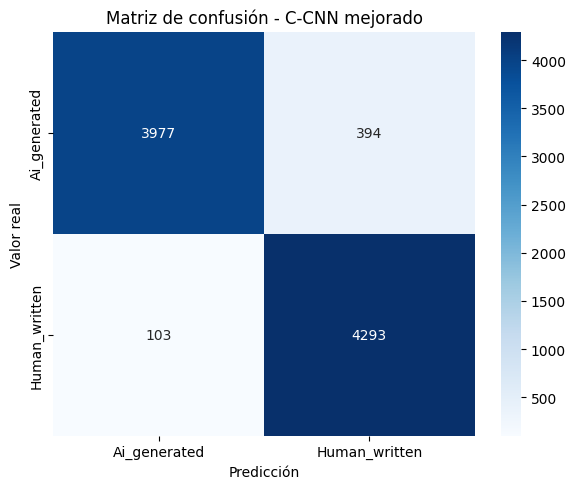

In [16]:
# ================================================================
# CELDA 2 – MODELO C-CNN MEJORADO (GLOBAL MAX POOLING)
# ================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------------
# 2.1 Carga de los conjuntos generados en la Celda 1
# -----------------------------------------------
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

X_train_raw = train_df['code'].astype(str).tolist()
X_test_raw = test_df['code'].astype(str).tolist()
y_train = train_df['target'].values
y_test = test_df['target'].values

print(f"Muestras de entrenamiento: {len(X_train_raw)}")
print(f"Muestras de test: {len(X_test_raw)}")
print(f"Clases: {np.unique(y_train)}")

# -----------------------------------------------
# 2.2 Tokenización y padding (igual que antes)
# -----------------------------------------------
MAX_WORDS = 10000
MAX_LEN = 500

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

num_classes = len(np.unique(y_train))
print(f"Forma X_train: {X_train_pad.shape}, Forma X_test: {X_test_pad.shape}, Clases: {num_classes}")

# -----------------------------------------------
# 2.3 Definición del modelo C-CNN mejorado
# -----------------------------------------------
def build_c_cnn_v2(vocab_size,
                   embedding_dim=256,
                   max_length=MAX_LEN,
                   num_classes=num_classes,
                   filter_sizes=(3, 4, 5),
                   num_filters=128,
                   dropout_rate=0.5,          # antes 1-0.6 = 0.4
                   l2_strength=0.001):        # antes 0.01, reducido

    inputs = layers.Input(shape=(max_length,), dtype='int32', name='input_tokens')

    # Embedding de palabras (sin máscara)
    embedding = layers.Embedding(input_dim=vocab_size,
                                 output_dim=embedding_dim,
                                 mask_zero=False,
                                 name='word_embedding')(inputs)

    conv_outputs = []
    l2_reg = regularizers.l2(l2_strength)

    for f_size in filter_sizes:
        # Convolución 1D con regularización L2
        conv = layers.Conv1D(filters=num_filters,
                             kernel_size=f_size,
                             strides=1,
                             padding='valid',
                             activation='relu',
                             kernel_regularizer=l2_reg,
                             bias_regularizer=l2_reg,
                             name=f'conv_{f_size}')(embedding)

        # Global Max Pooling 1D: reduce a un vector de longitud = num_filters
        pool = layers.GlobalMaxPooling1D(name=f'global_maxpool_{f_size}')(conv)

        conv_outputs.append(pool)

    # Concatenación de los vectores (cada uno de 128)
    concatenated = layers.Concatenate(name='concatenate')(conv_outputs) if len(conv_outputs) > 1 else conv_outputs[0]

    # Dropout (mayor tasa para combatir sobreajuste)
    dropout = layers.Dropout(rate=dropout_rate, name='dropout')(concatenated)

    # Capa oculta pequeña (opcional, aquí la añado con 64 neuronas para un extra de capacidad)
    # Si quieres omitirla, conecta dropout directamente a la capa de salida.
    dense = layers.Dense(64,
                         activation='relu',
                         kernel_regularizer=l2_reg,
                         bias_regularizer=l2_reg,
                         name='dense_hidden')(dropout)

    # Capa de salida softmax
    outputs = layers.Dense(num_classes,
                           activation='softmax',
                           kernel_regularizer=l2_reg,
                           bias_regularizer=l2_reg,
                           name='output')(dense)

    model = models.Model(inputs=inputs, outputs=outputs, name='C_CNN_v2')

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
model = build_c_cnn_v2(vocab_size=vocab_size,
                       embedding_dim=256,
                       max_length=MAX_LEN,
                       num_classes=num_classes,
                       filter_sizes=(3, 4, 5),
                       num_filters=128,
                       dropout_rate=0.5,
                       l2_strength=0.001)

model.summary()

# -----------------------------------------------
# 2.4 Entrenamiento con más herramientas
# -----------------------------------------------
BATCH_SIZE = 128
EPOCHS = 50

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

print("\nIniciando entrenamiento del modelo mejorado...")
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# -----------------------------------------------
# 2.5 Evaluación final
# -----------------------------------------------
print("\nEvaluación en conjunto de test:")
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Ai_generated', 'Human_written']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ai_generated', 'Human_written'],
            yticklabels=['Ai_generated', 'Human_written'])
plt.title('Matriz de confusión - C‑CNN mejorado')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()

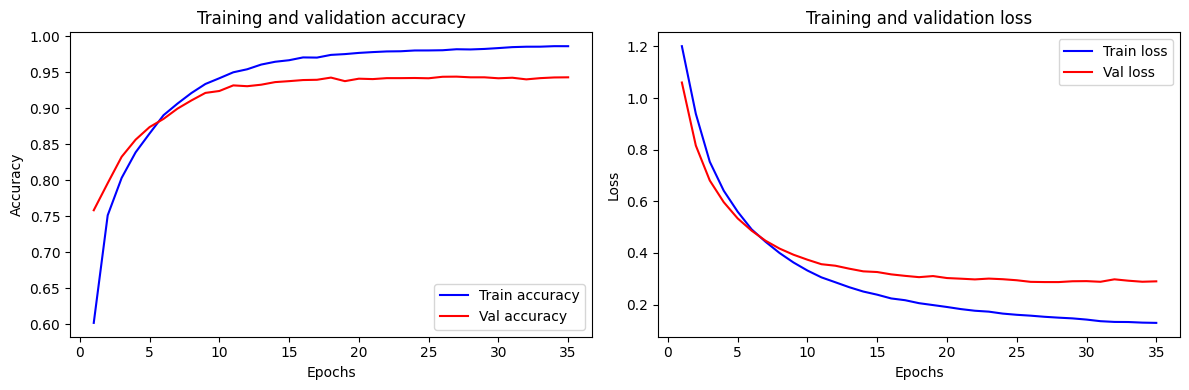

In [17]:
history_head = history
acc = history_head.history['accuracy']
val_acc = history_head.history['val_accuracy']
loss = history_head.history['loss']
val_loss = history_head.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Train accuracy')
plt.plot(epochs, val_acc, 'r-', label='Val accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Train loss')
plt.plot(epochs, val_loss, 'r-', label='Val loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()